In [1]:
import pandas as pd
import numpy as np

df_clean = pd.read_csv(
    "../data/processed/cleaned_online_retail.csv",
    parse_dates=["InvoiceDate"]
)

df_clean.head()

/Users/garv/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [2]:
top_products = (
    df_clean.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
REGENCY CAKESTAND 3 TIER              286486.30
WHITE HANGING HEART T-LIGHT HOLDER    252072.46
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                152340.57
JUMBO BAG RED RETROSPOT               136980.08
ASSORTED COLOUR BIRD ORNAMENT         127074.17
POSTAGE                               126563.04
PARTY BUNTING                         103880.23
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         79594.33
Name: Revenue, dtype: float64

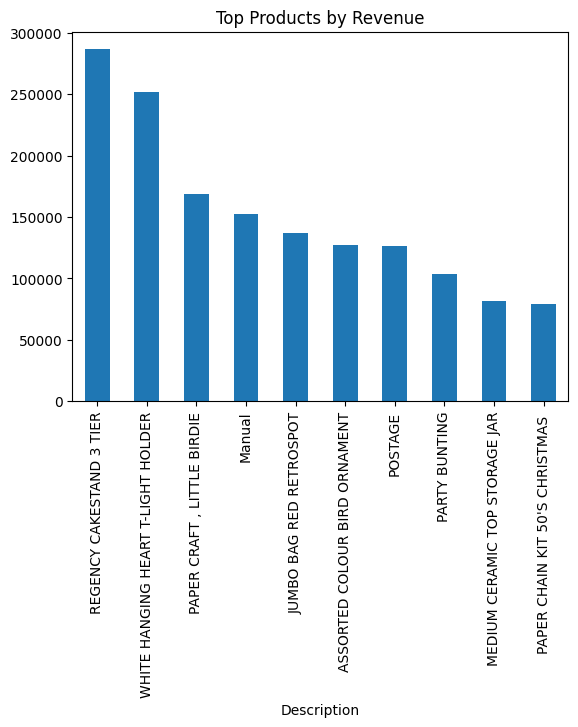

In [3]:
import matplotlib.pyplot as plt

plt.figure()
top_products.plot(kind="bar")
plt.title("Top Products by Revenue")

plt.savefig("../outputs/figures/top_products_revenue.png", bbox_inches="tight")

plt.show()

In [4]:
top_quantity = (
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     109169
WHITE HANGING HEART T-LIGHT HOLDER     93640
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          79913
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                75759
BROCADE RING PURSE                     71129
PACK OF 60 PINK PAISLEY CAKE CASES     55270
60 TEATIME FAIRY CAKE CASES            53495
PACK OF 72 RETROSPOT CAKE CASES        46107
Name: Quantity, dtype: int64

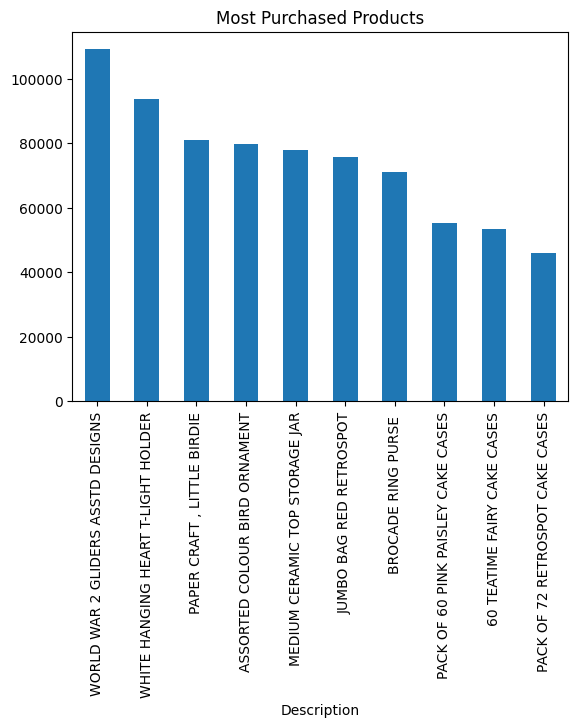

In [5]:
plt.figure()
top_quantity.plot(kind="bar")
plt.title("Most Purchased Products")

plt.savefig("../outputs/figures/top_products_quantity.png", bbox_inches="tight")

plt.show()

In [6]:
repeat_products = (
    df_clean.groupby("Description")["Invoice"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

repeat_products

Description
WHITE HANGING HEART T-LIGHT HOLDER    4888
REGENCY CAKESTAND 3 TIER              3318
ASSORTED COLOUR BIRD ORNAMENT         2652
JUMBO BAG RED RETROSPOT               2612
PARTY BUNTING                         2078
LUNCH BAG  BLACK SKULL.               1997
LUNCH BAG SPACEBOY DESIGN             1874
REX CASH+CARRY JUMBO SHOPPER          1857
HOME BUILDING BLOCK WORD              1831
STRAWBERRY CERAMIC TRINKET BOX        1818
Name: Invoice, dtype: int64

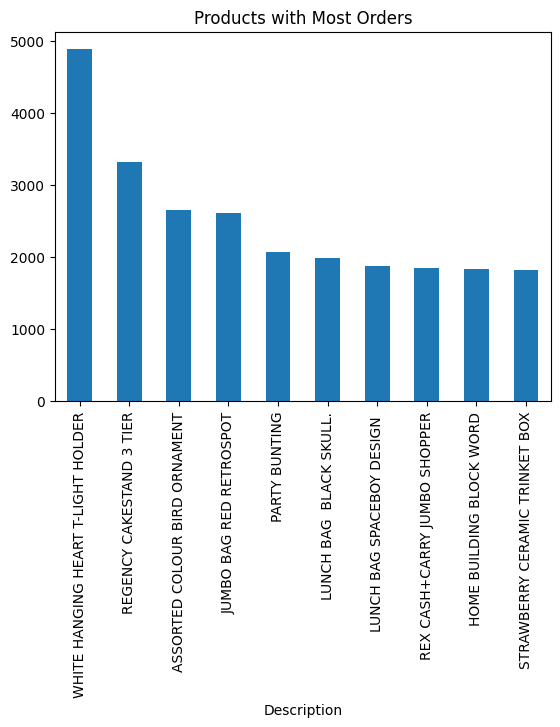

In [7]:
plt.figure()
repeat_products.plot(kind="bar")
plt.title("Products with Most Orders")

plt.savefig("../outputs/figures/repeat_products.png", bbox_inches="tight")

plt.show()

## Product Insights

Some products generate high revenue but low frequency.
Some products are frequently purchased but low value.
Top products drive repeat purchases.
Inventory planning should focus on high-frequency items.